In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/nasa_power_daily_raw.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

df.head()


,city,latitude,longitude,date,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M
0,London,51.5074,-0.1278,2016-01-01,5.17,7.09,2.47,5.18,94.66,3.94
1,London,51.5074,-0.1278,2016-01-02,8.58,9.52,6.72,3.50,95.32,5.20
2,London,51.5074,-0.1278,2016-01-03,6.55,8.29,4.25,11.59,96.01,4.50
3,London,51.5074,-0.1278,2016-01-04,7.05,8.49,5.85,6.88,95.86,3.68
4,London,51.5074,-0.1278,2016-01-05,7.32,9.28,5.91,3.12,96.07,2.04


In [2]:
print("Cities:", df["city"].nunique(), sorted(df["city"].unique()))
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Total rows:", len(df))

# rows per city
df.groupby("city").size()


Cities: 5 ['Birmingham', 'Bristol', 'Leeds', 'London', 'Manchester']
Date range: 2016-01-01 to 2022-12-31
Total rows: 12785


city
Birmingham    2557
Bristol       2557
Leeds         2557
London        2557
Manchester    2557
dtype: int64

In [3]:
df.isna().mean().sort_values(ascending=False)


city           0.0
latitude       0.0
longitude      0.0
date           0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
dtype: float64

In [4]:
cols = [
    "city",
    "date",
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
]

df = df[cols].copy()
df.head()


,city,date,T2M,T2M_MAX,T2M_MIN
0,London,2016-01-01,5.17,7.09,2.47
1,London,2016-01-02,8.58,9.52,6.72
2,London,2016-01-03,6.55,8.29,4.25
3,London,2016-01-04,7.05,8.49,5.85
4,London,2016-01-05,7.32,9.28,5.91


In [5]:
df["month"] = df["date"].dt.month

monthly_stats = (
    df.groupby(["city", "month"])
      .agg(
          mean_temp=("T2M", "mean"),
          std_temp=("T2M", "std")
      )
      .reset_index()
)

monthly_stats.head()


,city,month,mean_temp,std_temp
0,Birmingham,1,3.645945,2.842293
1,Birmingham,2,4.553333,3.153025
2,Birmingham,3,5.967327,2.630457
3,Birmingham,4,7.977429,2.743403
4,Birmingham,5,11.781613,2.711056


In [6]:
df["year"] = df["date"].dt.year

annual_mean = (
    df.groupby(["city", "year"])["T2M"]
      .mean()
      .reset_index()
)

annual_mean.head()


,city,year,T2M
0,Birmingham,2016,9.479945
1,Birmingham,2017,9.850192
2,Birmingham,2018,9.872384
3,Birmingham,2019,9.770329
4,Birmingham,2020,9.978197


In [7]:
# monthly climatology per city
climatology = (
    df.groupby(["city", "month"])["T2M"]
      .mean()
      .reset_index()
      .rename(columns={"T2M": "monthly_clim"})
)

# merge back
df = df.merge(climatology, on=["city", "month"], how="left")

# deseasonalised temperature
df["T2M_deseasonal"] = df["T2M"] - df["monthly_clim"]

df[["city", "date", "T2M", "monthly_clim", "T2M_deseasonal"]].head()


,city,date,T2M,monthly_clim,T2M_deseasonal
0,London,2016-01-01,5.17,4.019631,1.150369
1,London,2016-01-02,8.58,4.019631,4.560369
2,London,2016-01-03,6.55,4.019631,2.530369
3,London,2016-01-04,7.05,4.019631,3.030369
4,London,2016-01-05,7.32,4.019631,3.300369


In [8]:
df = df.sort_values(["city", "date"])

for window in [7, 30]:
    df[f"roll_mean_{window}"] = (
        df.groupby("city")["T2M_deseasonal"]
          .transform(lambda x: x.rolling(window, center=True).mean())
    )

    df[f"roll_std_{window}"] = (
        df.groupby("city")["T2M_deseasonal"]
          .transform(lambda x: x.rolling(window, center=True).std())
    )

df.head()


,city,date,T2M,T2M_MAX,T2M_MIN,month,year,monthly_clim,T2M_deseasonal,roll_mean_7,roll_std_7,roll_mean_30,roll_std_30
2557,Birmingham,2016-01-01,3.69,6.15,0.85,1,2016,3.645945,0.044055,NaN,NaN,NaN,NaN
2558,Birmingham,2016-01-02,7.26,8.95,5.75,1,2016,3.645945,3.614055,NaN,NaN,NaN,NaN
2559,Birmingham,2016-01-03,5.75,7.22,3.66,1,2016,3.645945,2.104055,NaN,NaN,NaN,NaN
2560,Birmingham,2016-01-04,6.07,6.97,5.56,1,2016,3.645945,2.424055,1.721198,1.277507,NaN,NaN
2561,Birmingham,2016-01-05,6.14,7.64,4.78,1,2016,3.645945,2.494055,1.694055,1.320379,NaN,NaN


In [9]:
df.groupby("city")[["T2M_deseasonal"]].agg(["mean", "std", "min", "max"])


T2M_deseasonal                              
                     mean       std       min       max
city                                                   
Birmingham  -1.583924e-16  2.660908 -9.827327  7.974381
Bristol     -6.321802e-17  2.582478 -9.883687  8.388524
Leeds       -1.180996e-17  2.523512 -7.928940  8.335714
London      -8.336442e-18  2.734324 -9.026452  8.062905
Manchester  -4.684038e-16  2.476088 -8.873502  7.157281

In [10]:
print(df.columns)

Index(['city', 'date', 'T2M', 'T2M_MAX', 'T2M_MIN', 'month', 'year',
       'monthly_clim', 'T2M_deseasonal', 'roll_mean_7', 'roll_std_7',
       'roll_mean_30', 'roll_std_30'],
      dtype='object')


In [11]:
df.head()

,city,date,T2M,T2M_MAX,T2M_MIN,month,year,monthly_clim,T2M_deseasonal,roll_mean_7,roll_std_7,roll_mean_30,roll_std_30
2557,Birmingham,2016-01-01,3.69,6.15,0.85,1,2016,3.645945,0.044055,NaN,NaN,NaN,NaN
2558,Birmingham,2016-01-02,7.26,8.95,5.75,1,2016,3.645945,3.614055,NaN,NaN,NaN,NaN
2559,Birmingham,2016-01-03,5.75,7.22,3.66,1,2016,3.645945,2.104055,NaN,NaN,NaN,NaN
2560,Birmingham,2016-01-04,6.07,6.97,5.56,1,2016,3.645945,2.424055,1.721198,1.277507,NaN,NaN
2561,Birmingham,2016-01-05,6.14,7.64,4.78,1,2016,3.645945,2.494055,1.694055,1.320379,NaN,NaN


In [12]:
annual_city = (
    df.groupby(['city','year'])['T2M']
    .mean()
    .unstack()
)

print("Annual Mean Temperature (°C):")
print(annual_city.round(2))

warming_change = annual_city.iloc[:,-1] - annual_city.iloc[:,0]

print("\nTotal Temperature Change (First → Last Year):")
print(warming_change.sort_values(ascending=False).round(2))

Annual Mean Temperature (°C):
year         2016   2017   2018   2019   2020   2021   2022
city                                                       
Birmingham   9.48   9.85   9.87   9.77   9.98   9.60  10.49
Bristol     10.16  10.56  10.66  10.41  10.75  10.33  11.31
Leeds        9.05   9.39   9.39   9.38   9.54   9.31  10.09
London      10.35  10.66  10.89  10.64  11.00  10.21  11.56
Manchester   9.03   9.43   9.37   9.26   9.52   9.34  10.01

Total Temperature Change (First → Last Year):
city
London        1.20
Bristol       1.15
Leeds         1.04
Birmingham    1.01
Manchester    0.98
dtype: float64


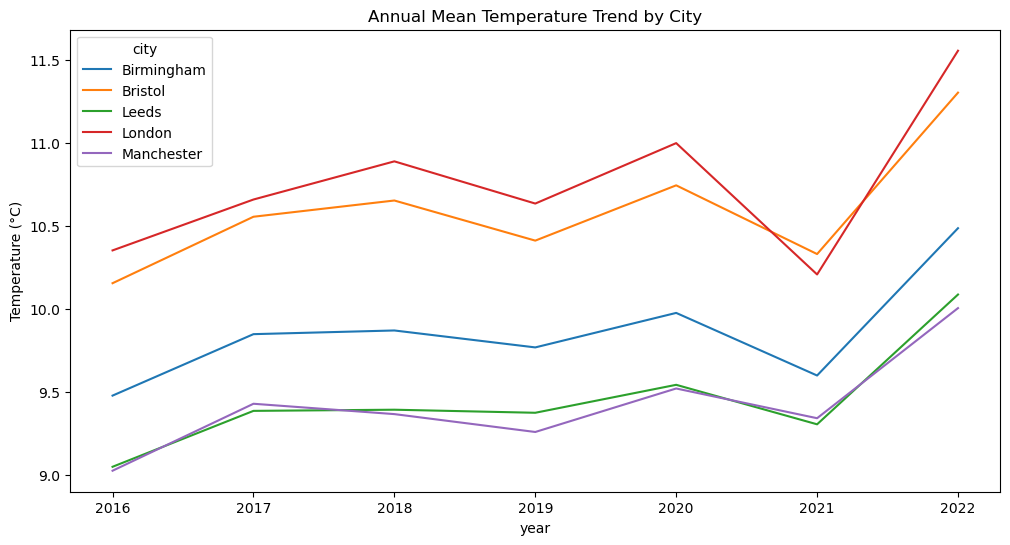

In [13]:
import matplotlib.pyplot as plt
annual_city.T.plot(figsize=(12,6))
plt.title("Annual Mean Temperature Trend by City")
plt.ylabel("Temperature (°C)")
plt.show()

In [14]:
seasonal_range = (
    df.groupby(['city','month'])['monthly_clim']
    .mean()
    .groupby(level=0)
    .apply(lambda x: x.max() - x.min())
)

print("Seasonal Temperature Range per City (°C):")
print(seasonal_range.sort_values(ascending=False).round(2))

Seasonal Temperature Range per City (°C):
city
London        14.45
Birmingham    13.42
Leeds         13.17
Bristol       13.14
Manchester    12.25
Name: monthly_clim, dtype: float64


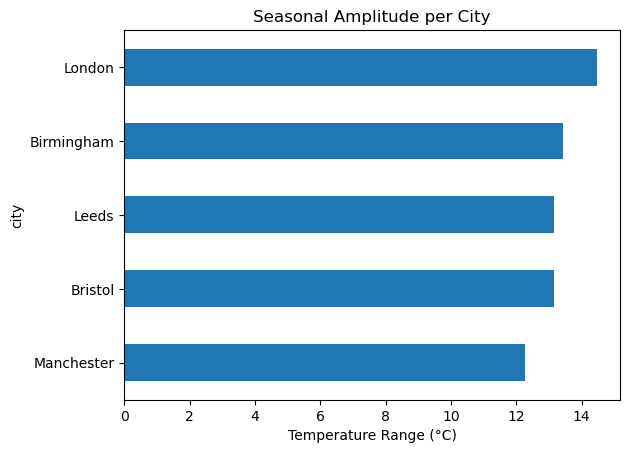

In [15]:
seasonal_range.sort_values().plot(kind='barh')
plt.title("Seasonal Amplitude per City")
plt.xlabel("Temperature Range (°C)")
plt.show()

In [16]:
volatility_city = df.groupby('city')['roll_std_30'].mean()

print("Average 30-Day Rolling Volatility (°C):")
print(volatility_city.sort_values(ascending=False).round(2))

Average 30-Day Rolling Volatility (°C):
city
London        2.43
Birmingham    2.39
Bristol       2.28
Leeds         2.27
Manchester    2.22
Name: roll_std_30, dtype: float64


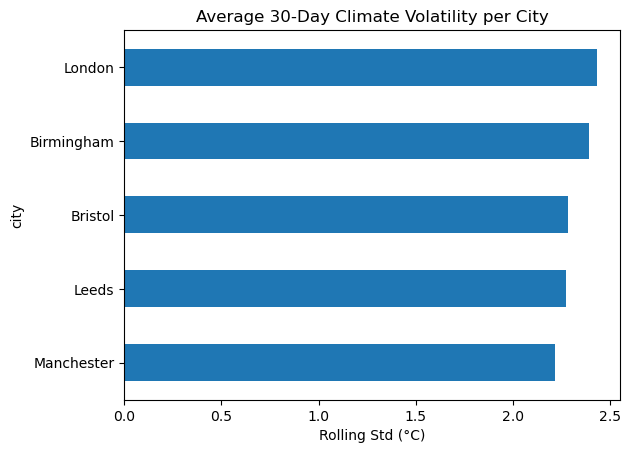

In [17]:
volatility_city.sort_values().plot(kind='barh')
plt.title("Average 30-Day Climate Volatility per City")
plt.xlabel("Rolling Std (°C)")
plt.show()

In [18]:
columns_to_keep = [
    'city',
    'year',
    'month',
    'T2M_deseasonal',
    'roll_std_30'
]

df_model = df[columns_to_keep].copy()

print("Shape after selection:", df_model.shape)

Shape after selection: (12785, 5)


In [19]:
print(df_model.isna().sum())

df_model = df_model.dropna()

print("Shape after dropping NaN:", df_model.shape)

city                0
year                0
month               0
T2M_deseasonal      0
roll_std_30       145
dtype: int64
Shape after dropping NaN: (12640, 5)


In [20]:
df_model['abs_dev'] = abs(df_model['T2M_deseasonal'])

In [21]:
df_model['volatility_interaction'] = (
    df_model['T2M_deseasonal'] * df_model['roll_std_30']
)

In [22]:
features = [
    'T2M_deseasonal',
    'roll_std_30',
    'abs_dev',
    'volatility_interaction'
]

X = df_model[features]

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (12640, 4)


In [23]:
# Time-based split
train = df_model[df_model['year'] <= 2020].copy()
test  = df_model[df_model['year'] > 2020].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (9060, 7)
Test shape: (3580, 7)


In [24]:
features = [
    'T2M_deseasonal',
    'roll_std_30',
    'abs_dev'
]

X_train = train[features]
X_test  = test[features]

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Isolation Forest

In [26]:
from sklearn.ensemble import IsolationForest
import time
import numpy as np

# ---- Baseline Parameters ----
baseline_params = {
    "n_estimators": 200,
    "contamination": 0.05
}

start = time.time()

baseline_if = IsolationForest(
    random_state=42,
    **baseline_params
)

baseline_if.fit(X_train_scaled)

end = time.time()

baseline_time = round(end - start, 4)

baseline_train_scores = baseline_if.decision_function(X_train_scaled)
baseline_test_scores  = baseline_if.decision_function(X_test_scaled)

# Predictions
baseline_train_preds = np.where(
    baseline_if.predict(X_train_scaled) == -1, 1, 0
)

baseline_test_preds = np.where(
    baseline_if.predict(X_test_scaled) == -1, 1, 0
)

print("Baseline Training Time:", baseline_time, "seconds")
print("Baseline Train Anomaly %:", round(baseline_train_preds.mean()*100,2))
print("Baseline Test Anomaly %:", round(baseline_test_preds.mean()*100,2))

Baseline Training Time: 0.4801 seconds
Baseline Train Anomaly %: 5.0
Baseline Test Anomaly %: 8.6


In [27]:
start_pred = time.time()
train.loc[:, 'anomaly_raw'] = baseline_if.predict(X_train_scaled)
test.loc[:, 'anomaly_raw']  = baseline_if.predict(X_test_scaled)

end_pred = time.time()

prediction_time = round(end_pred - start_pred,4)

print("Prediction Time:", prediction_time)

Prediction Time: 0.1823


In [28]:
train.loc[:, 'anomaly'] = train['anomaly_raw'].map({1:0, -1:1})
test.loc[:, 'anomaly']  = test['anomaly_raw'].map({1:0, -1:1})

In [29]:
print("Train raw counts:")
print(train['anomaly_raw'].value_counts())

print("\nTrain anomaly %:",
      round(train['anomaly'].mean()*100, 2))

print("\nTest anomaly %:",
      round(test['anomaly'].mean()*100, 2))

Train raw counts:
anomaly_raw
 1    8607
-1     453
Name: count, dtype: int64

Train anomaly %: 5.0

Test anomaly %: 8.6


In [30]:
train_rate = train['anomaly'].mean()
test_rate = test['anomaly'].mean()

stability_gap = abs(train_rate - test_rate)

print("Stability gap:", round(stability_gap*100, 2), "%")

Stability gap: 3.6 %


In [31]:
train.loc[:, 'anomaly_score'] = baseline_if.decision_function(X_train_scaled)
test.loc[:, 'anomaly_score']  = baseline_if.decision_function(X_test_scaled)

In [32]:
print(train[['anomaly_score']].head())
print("\nTest sample:")
print(test[['anomaly_score']].head())

      anomaly_score
2572       0.080243
2573       0.109381
2574       0.107882
2575       0.069563
2576       0.067287

Test sample:
      anomaly_score
4384       0.111895
4385       0.087188
4386       0.150968
4387       0.151736
4388       0.115400


In [33]:
# ---- Baseline Separation ----
baseline_normal_scores = baseline_train_scores[baseline_train_preds == 0]
baseline_anomaly_scores = baseline_train_scores[baseline_train_preds == 1]

baseline_sep = baseline_normal_scores.mean() - baseline_anomaly_scores.mean()

print("Baseline Mean (Normal):", round(baseline_normal_scores.mean(), 4))
print("Baseline Mean (Anomaly):", round(baseline_anomaly_scores.mean(), 4))
print("Baseline Separation:", round(baseline_sep, 4))

Baseline Mean (Normal): 0.1135
Baseline Mean (Anomaly): -0.0441
Baseline Separation: 0.1576


In [34]:
# Define extreme threshold
threshold = 3 * train['T2M_deseasonal'].std()

extreme_events = train[abs(train['T2M_deseasonal']) > threshold]

captured_extremes = extreme_events['anomaly'].sum()

capture_rate = captured_extremes / len(extreme_events)

print("Extreme event capture rate:",
      round(capture_rate*100, 2), "%")

Extreme event capture rate: 100.0 %


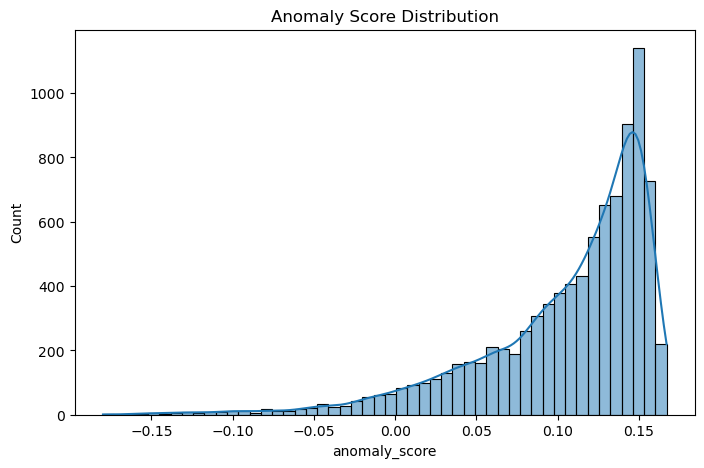

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(train['anomaly_score'], bins=50, kde=True)
plt.title("Anomaly Score Distribution")
plt.show()

In [36]:
# Train city-wise anomaly %
train_city_anomaly = (
    train.groupby('city')['anomaly']
    .mean() * 100
)

print("Train City-wise Anomaly %:")
print(train_city_anomaly.sort_values(ascending=False).round(2))

Train City-wise Anomaly %:
city
London        6.18
Birmingham    6.13
Bristol       5.24
Leeds         3.81
Manchester    3.64
Name: anomaly, dtype: float64


In [37]:
# Test city-wise anomaly %
test_city_anomaly = (
    test.groupby('city')['anomaly']
    .mean() * 100
)

print("\nTest City-wise Anomaly %:")
print(test_city_anomaly.sort_values(ascending=False).round(2))


Test City-wise Anomaly %:
city
London        10.47
Birmingham    10.20
Bristol       10.06
Leeds          6.28
Manchester     6.01
Name: anomaly, dtype: float64


In [38]:
city_comparison = pd.DataFrame({
    'Train %': train_city_anomaly,
    'Test %': test_city_anomaly
})

print("\nCity-wise Comparison:")
print(city_comparison.round(2))


City-wise Comparison:
            Train %  Test %
city                       
Birmingham     6.13   10.20
Bristol        5.24   10.06
Leeds          3.81    6.28
London         6.18   10.47
Manchester     3.64    6.01


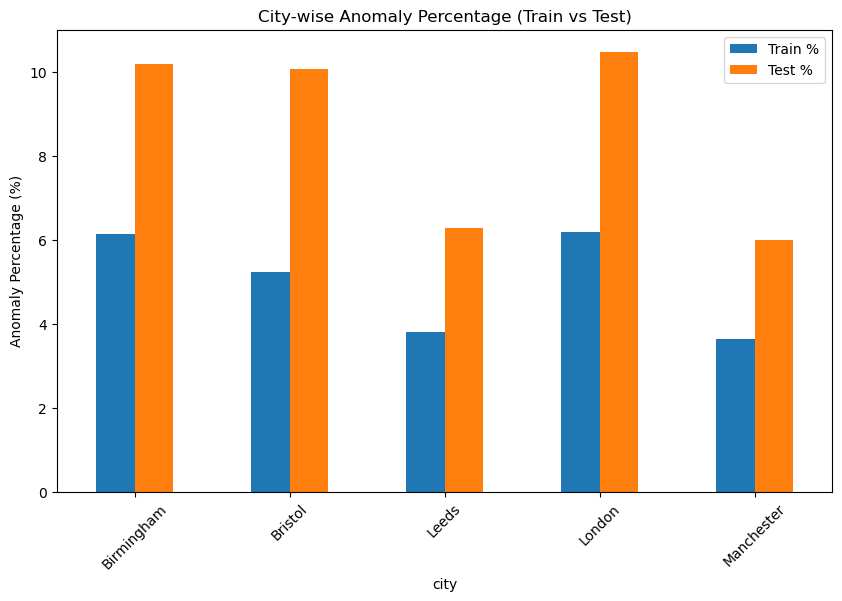

In [39]:
import matplotlib.pyplot as plt

city_comparison.plot(kind='bar', figsize=(10,6))
plt.title("City-wise Anomaly Percentage (Train vs Test)")
plt.ylabel("Anomaly Percentage (%)")
plt.xticks(rotation=45)
plt.show()

In [40]:
city_coords = pd.DataFrame({
    'city': ['London', 'Birmingham', 'Bristol', 'Leeds', 'Manchester'],
    'latitude': [51.5074, 52.4862, 51.4545, 53.8008, 53.4808],
    'longitude': [-0.1278, -1.8904, -2.5879, -1.5491, -2.2426]
})

In [41]:
test_city_anomaly = (
    test.groupby('city')['anomaly']
    .mean()
    .reset_index()
)

test_city_anomaly['anomaly_percent'] = (
    test_city_anomaly['anomaly'] * 100
)

In [42]:
city_map_data = test_city_anomaly.merge(
    city_coords,
    on='city',
    how='left'
)

print(city_map_data.round(2))

         city  anomaly  anomaly_percent  latitude  longitude
0  Birmingham     0.10            10.20     52.49      -1.89
1     Bristol     0.10            10.06     51.45      -2.59
2       Leeds     0.06             6.28     53.80      -1.55
3      London     0.10            10.47     51.51      -0.13
4  Manchester     0.06             6.01     53.48      -2.24


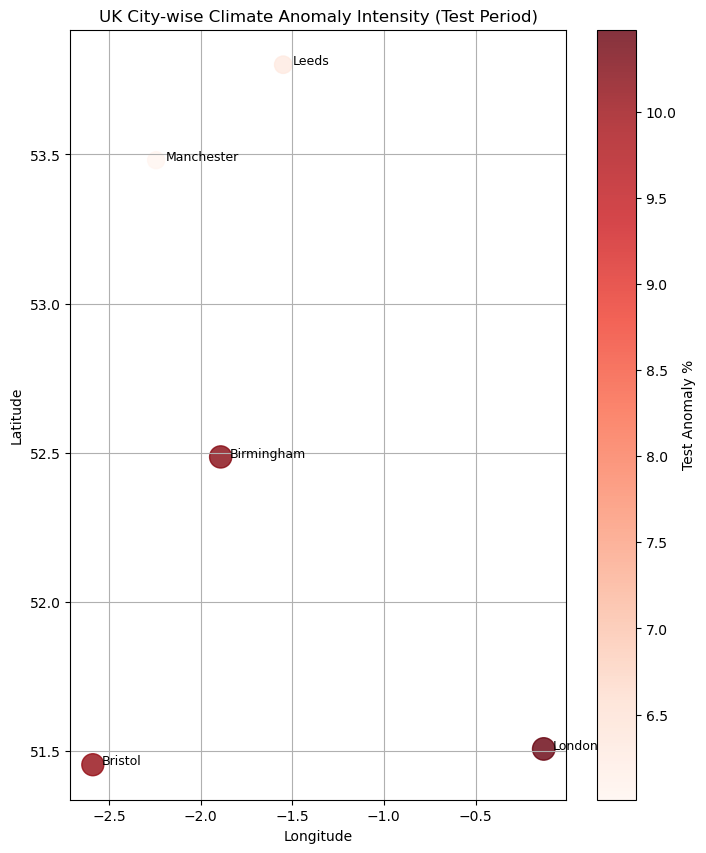

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,10))

scatter = plt.scatter(
    city_map_data['longitude'],
    city_map_data['latitude'],
    s=city_map_data['anomaly_percent'] * 25,
    c=city_map_data['anomaly_percent'],
    cmap='Reds',
    alpha=0.8
)

for _, row in city_map_data.iterrows():
    plt.text(row['longitude'] + 0.05,
             row['latitude'],
             row['city'],
             fontsize=9)

plt.colorbar(scatter, label='Test Anomaly %')
plt.title("UK City-wise Climate Anomaly Intensity (Test Period)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [44]:
features = [
    'T2M_deseasonal',
    'roll_std_30',
    'abs_dev'
]

heatmap_df = train[features + ['anomaly']].copy()

print("Heatmap Data Sample:")
print(heatmap_df.head())

Heatmap Data Sample:
      T2M_deseasonal  roll_std_30   abs_dev  anomaly
2572       -3.735945     3.026544  3.735945        0
2573       -2.835945     3.052329  2.835945        0
2574       -1.965945     3.089044  1.965945        0
2575       -4.115945     3.082419  4.115945        0
2576       -4.085945     3.092990  4.085945        0


In [45]:
correlation_matrix = heatmap_df.corr()

print("Correlation Matrix:\n")
print(correlation_matrix.round(3))

Correlation Matrix:

                T2M_deseasonal  roll_std_30  abs_dev  anomaly
T2M_deseasonal           1.000       -0.019   -0.020    0.047
roll_std_30             -0.019        1.000    0.278    0.222
abs_dev                 -0.020        0.278    1.000    0.488
anomaly                  0.047        0.222    0.488    1.000


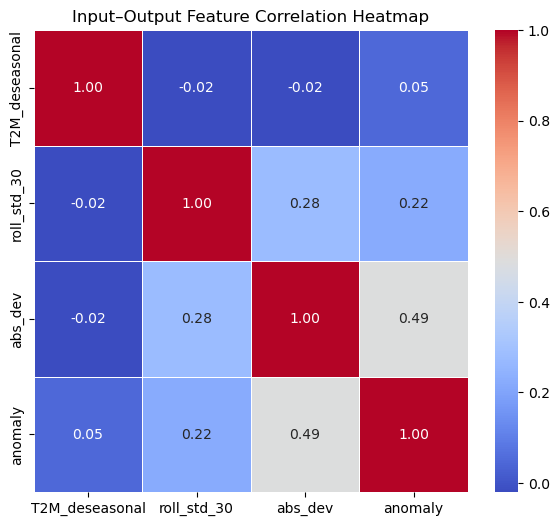

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Input–Output Feature Correlation Heatmap")
plt.show()

Feature → Anomaly Correlation:
                anomaly
T2M_deseasonal    0.047
roll_std_30       0.222
abs_dev           0.488


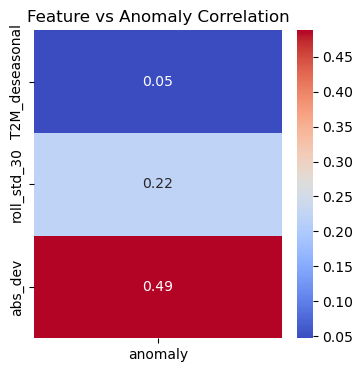

In [47]:
feature_anomaly_corr = correlation_matrix[['anomaly']].drop('anomaly')

print("Feature → Anomaly Correlation:")
print(feature_anomaly_corr.round(3))

plt.figure(figsize=(4,4))

sns.heatmap(
    feature_anomaly_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Feature vs Anomaly Correlation")
plt.show()

Hyperparameter Tuning (Isolation Forest)

In [48]:
from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import IsolationForest
import numpy as np

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_samples": ["auto", 0.8],
    "contamination": [0.03, 0.05, 0.08],
    "max_features": [1.0, 0.8]
}

best_score = -np.inf
best_params = None

for params in ParameterGrid(param_grid):

    model = IsolationForest(random_state=42, **params)
    model.fit(X_train_scaled)

    scores = model.decision_function(X_train_scaled)
    preds = model.predict(X_train_scaled)
    preds = np.where(preds == -1, 1, 0)

    normal_scores = scores[preds == 0]
    anomaly_scores = scores[preds == 1]

    separation = normal_scores.mean() - anomaly_scores.mean()

    if separation > best_score:
        best_score = separation
        best_params = params

print("Best Parameters:", best_params)
print("Best Separation Score:", round(best_score,4))

Best Parameters: {'contamination': 0.03, 'max_features': 1.0, 'max_samples': 'auto', 'n_estimators': 300}
Best Separation Score: 0.1778


In [49]:
best_if = IsolationForest(
    random_state=42,
    **best_params
)

best_if.fit(X_train_scaled)

train_scores = best_if.decision_function(X_train_scaled)
test_scores  = best_if.decision_function(X_test_scaled)

train_preds = best_if.predict(X_train_scaled)
test_preds  = best_if.predict(X_test_scaled)

train_preds = np.where(train_preds == -1, 1, 0)
test_preds  = np.where(test_preds == -1, 1, 0)

print("Train anomaly %:", round(train_preds.mean()*100,2))
print("Test anomaly %:", round(test_preds.mean()*100,2))

Train anomaly %: 3.0
Test anomaly %: 5.84


In [50]:
stability_gap = abs(train_preds.mean() - test_preds.mean())
print("New Stability Gap:", round(stability_gap*100,2), "%")

New Stability Gap: 2.84 %


In [51]:
import pandas as pd
import numpy as np

# ---- Baseline Metrics ----
baseline_train_anom = baseline_train_preds.mean() * 100
baseline_test_anom  = baseline_test_preds.mean() * 100
baseline_gap        = abs(baseline_train_preds.mean() - baseline_test_preds.mean()) * 100
baseline_sep        = (
    baseline_train_scores[baseline_train_preds == 0].mean()
    - baseline_train_scores[baseline_train_preds == 1].mean()
)

# ---- Tuned Metrics ----
tuned_train_anom = train_preds.mean() * 100
tuned_test_anom  = test_preds.mean() * 100
tuned_gap        = abs(train_preds.mean() - test_preds.mean()) * 100
tuned_sep        = (
    train_scores[train_preds == 0].mean()
    - train_scores[train_preds == 1].mean()
)

# ---- Results Table ----
results = pd.DataFrame({
    "Metric": [
        "Train Anomaly %",
        "Test Anomaly %",
        "Stability Gap %",
        "Separation Score"
    ],
    "Baseline IF": [
        round(baseline_train_anom, 2),
        round(baseline_test_anom, 2),
        round(baseline_gap, 2),
        round(baseline_sep, 4)
    ],
    "Tuned IF": [
        round(tuned_train_anom, 2),
        round(tuned_test_anom, 2),
        round(tuned_gap, 2),
        round(tuned_sep, 4)
    ]
})

results

,Metric,Baseline IF,Tuned IF
0,Train Anomaly %,5.0000,3.0000
1,Test Anomaly %,8.6000,5.8400
2,Stability Gap %,3.6000,2.8400
3,Separation Score,0.1576,0.1778


In [52]:
results["Improvement"] = results["Tuned IF"] - results["Baseline IF"]
results

,Metric,Baseline IF,Tuned IF,Improvement
0,Train Anomaly %,5.0000,3.0000,-2.0000
1,Test Anomaly %,8.6000,5.8400,-2.7600
2,Stability Gap %,3.6000,2.8400,-0.7600
3,Separation Score,0.1576,0.1778,0.0202


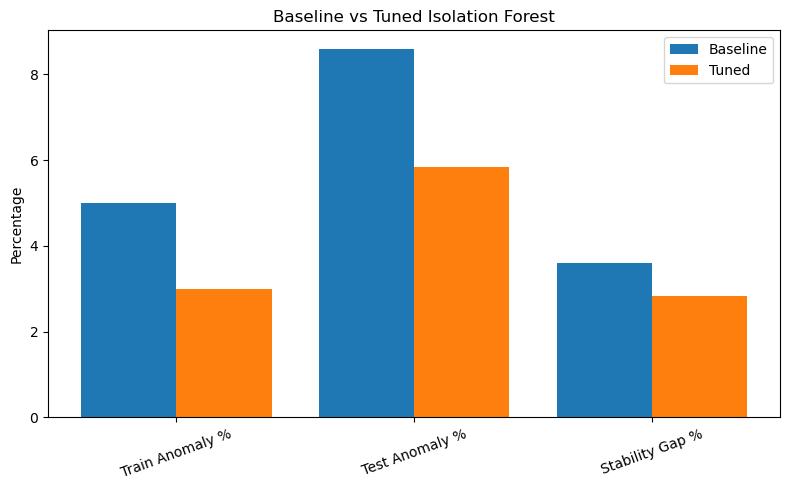

In [53]:
import matplotlib.pyplot as plt

metrics = ["Train Anomaly %", "Test Anomaly %", "Stability Gap %"]
baseline_vals = [5.00, 8.60, 3.60]
tuned_vals = [3.00, 5.84, 2.84]

x = range(len(metrics))

plt.figure(figsize=(8,5))
plt.bar(x, baseline_vals, width=0.4, label="Baseline", align='center')
plt.bar([i+0.4 for i in x], tuned_vals, width=0.4, label="Tuned", align='center')

plt.xticks([i+0.2 for i in x], metrics, rotation=20)
plt.ylabel("Percentage")
plt.title("Baseline vs Tuned Isolation Forest")
plt.legend()
plt.tight_layout()
plt.show()

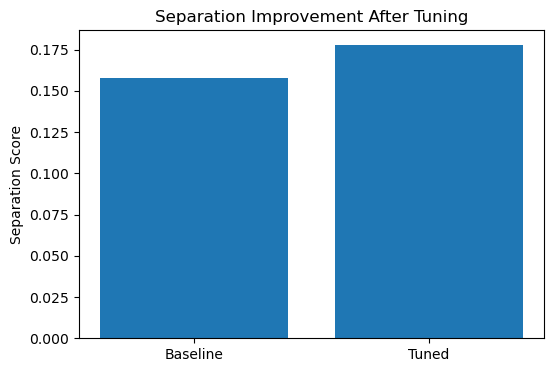

In [54]:
plt.figure(figsize=(6,4))
plt.bar(["Baseline", "Tuned"], [0.1576, 0.1778])
plt.ylabel("Separation Score")
plt.title("Separation Improvement After Tuning")
plt.show()

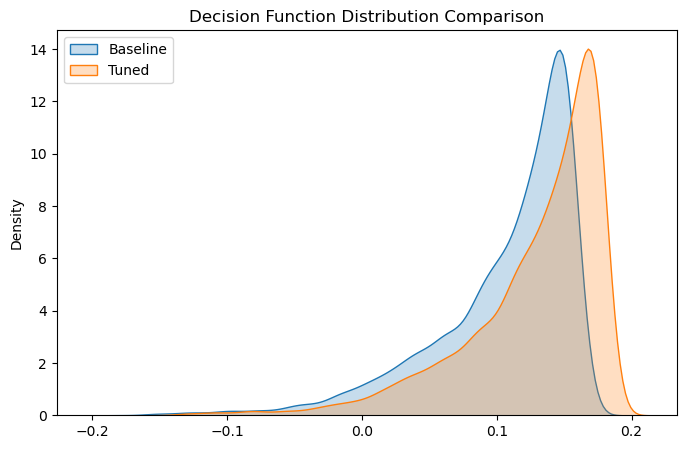

In [55]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(baseline_train_scores, label="Baseline", fill=True)
sns.kdeplot(train_scores, label="Tuned", fill=True)

plt.title("Decision Function Distribution Comparison")
plt.legend()
plt.show()

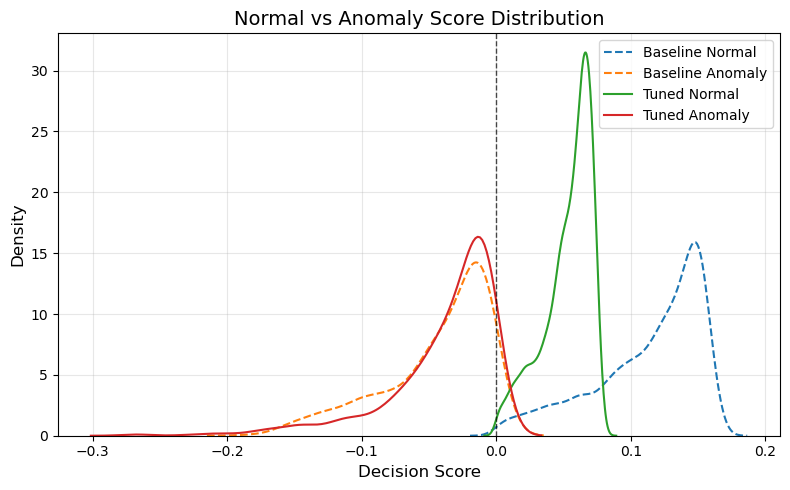

In [57]:
plt.figure(figsize=(8,5))

sns.kdeplot(baseline_normal_scores, label="Baseline Normal", linestyle="--")
sns.kdeplot(baseline_anomaly_scores, label="Baseline Anomaly", linestyle="--")

sns.kdeplot(normal_scores, label="Tuned Normal")
sns.kdeplot(anomaly_scores, label="Tuned Anomaly")

# ---- Add zero decision boundary line ----
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

plt.title("Normal vs Anomaly Score Distribution", fontsize=14)
plt.xlabel("Decision Score", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(fontsize=10)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()